<a href="https://colab.research.google.com/github/cemilkaracam/Haar-Wavelet-Regularized-Approximation-of-Discontinuous-Functions/blob/main/decomposition_haar_adl%C4%B1_dosyan%C4%B1n_kopyas%C4%B1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

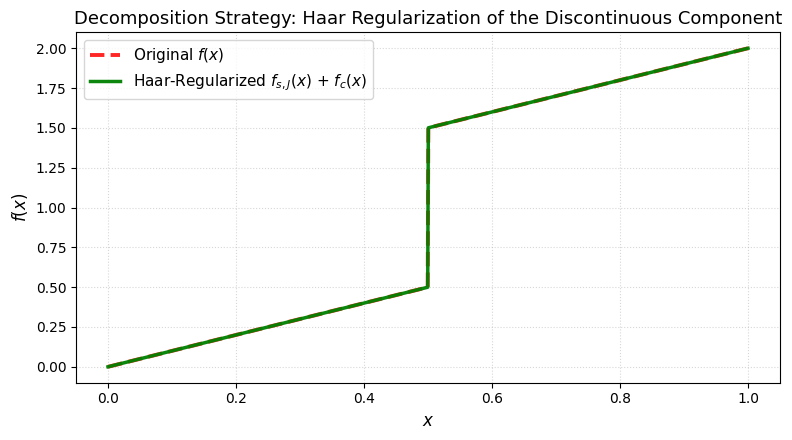

In [ ]:
# Gerekli paket kurulumu (ilk çalıştırmada ekle)
!pip install pywavelets

import numpy as np
import matplotlib.pyplot as plt
import pywt

# Domain discretization
x = np.linspace(0, 1, 1024)

# Smooth and discontinuous components
def f_c(x):
    return x

def f_s(x):
    return (x >= 0.5).astype(float)

f_original = f_c(x) + f_s(x)

# Haar regularization of the discontinuous component
def haar_regularize(fx, wavelet='haar', level=3):
    coeffs = pywt.wavedec(fx, wavelet, level=level)
    # Retain only the scaling coefficients; discard detail coefficients
    coeffs_trunc = [coeffs[0]] + [np.zeros_like(c) for c in coeffs[1:]]
    return pywt.waverec(coeffs_trunc, wavelet)[:len(fx)]

fs_smoothed = haar_regularize(f_s(x), level=3)
f_decomp = f_c(x) + fs_smoothed

# Visualization
plt.figure(figsize=(8, 4.5))
plt.plot(x, f_original, '--', color='red', linewidth=2.8,
         alpha=0.85, label='Original $f(x)$')
plt.plot(x, f_decomp, '-', color='green', linewidth=2.5,
         alpha=0.95, label='Haar-Regularized $f_{s,J}(x)$ + $f_c(x)$')

plt.title('Decomposition Strategy: Haar Regularization of the Discontinuous Component',
          fontsize=13)
plt.xlabel('$x$', fontsize=12)
plt.ylabel('$f(x)$', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()

# Grafiği hem kaydet hem göster
plt.savefig('decomposition_regularization_output.pdf', dpi=300)
plt.show()
